# Amostrando eventos para testes

In [1]:
import pickle
import random

In [2]:
FORCE_OVERWRITE = True
GENERATE_VIS = True
SEED = 2026
SAMPLE_SIZE = 500
random.seed(SEED)

In [3]:
events = pickle.load(open("/exp_local/kenzosaki/data/iptc/processed/politics_extracted_events.pkl", "rb"))

In [4]:
#event_sample = random.sample(events, SAMPLE_SIZE)
event_sample = events[:SAMPLE_SIZE] # mais simples

# Construindo o grafo

In [ ]:
from glm_based_event_analysis.utils.general import load_config
from glm_based_event_analysis.graph_construction.graph_builder import EventGraphBuilder

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.7.1+cu126).


In [6]:
CONFIG_PATH = "../src/glm_based_event_analysis/config/graph_construction/ai_news.yaml"

In [7]:
config = load_config(CONFIG_PATH, print_config=True)

Loaded configuration file (../src/glm_based_event_analysis/config/graph_construction/ai_news.yaml):
	 general: {'similarity_method': 'what', 'force_recompute': False, 'tmp_files_dir': '/home/kenzosaki/repos/glm-based-event-analysis/data/interim/ai_news/', 'embedding_model': 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2', 'encoding_batch_size': 128}
	 distance_to_similarity: {'time': 'exponential', 'time_args': {'alpha': 7}, 'spatial': 'exponential', 'spatial_args': {'alpha': 1000}}
	 constraints: {'use_non_zero_similarities': True, 'force_directed': True, 'semantic_similarity_range': [0.1, 1], 'spatial_distance_range': [0, '1e4'], 'time_days_range': [0, 31], 'max_neighbors': 100, 'filter_type': 'mad', 'threshold': 3.0}


In [8]:
# sobrescrevendo alguns parametros
config['general']['tmp_files_dir'] = '/home/kenzosaki/repos/glm-based-event-analysis/data/interim/'
config["general"]['force_recompute'] = FORCE_OVERWRITE
# config["constraints"]["filter_type"] = "iqr"
# config["constraints"]["threshold"] = 1.5

In [9]:
builder = EventGraphBuilder(config)
G = builder.build_graph(event_sample)

- Parsed 'where' info. Found 0 events with unknown location out of 498 total events.


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

- Saved what_similarities to /home/kenzosaki/repos/glm-based-event-analysis/data/interim/what_similarities.pkl
- Saved where_distance matrix to /home/kenzosaki/repos/glm-based-event-analysis/data/interim/where_distance_matrix.pkl
- Saved when_distance matrix to /home/kenzosaki/repos/glm-based-event-analysis/data/interim/when_distance_matrix.pkl
- Created graph with 498 nodes and 1234 edges. Number of connected components: 57


Connecting components: 100%|██████████| 56/56 [00:00<00:00, 58.86it/s]


In [10]:
# numero de arestas 
print(f"Number of edges: {G.number_of_edges()}")

Number of edges: 1290


In [11]:
events_df = builder.events_df

In [12]:
# carregando um grafo
#G = pickle.load(open("/exp_local/kenzosaki/data/iptc/graphs/politics_event_graph.pkl", "rb"))

# Construindo uma mascara temporal

Verificando, para cada evento, quais eventos são mais novos que ele (ocorreram depois).

In [13]:
import numpy as np
import pandas as pd
import seaborn as sns

In [14]:
events_df["when"] = pd.to_datetime(events_df["when"])

In [15]:
raw_dates = events_df["when"].tolist()
is_newer_mask = np.zeros((len(events_df), len(events_df)), dtype=bool)

In [16]:
for i in range(len(raw_dates)):
    for j in range(i + 1, len(raw_dates)):
        is_newer_mask[i, j] = raw_dates[i] < raw_dates[j]

In [17]:
# validando
print("Data de exemplo:",raw_dates[0])
print("Eventos que vieram depois que o evento 0:", np.array(raw_dates)[is_newer_mask[0]][:5])

Data de exemplo: 2026-05-31 20:39:10+00:00
Eventos que vieram depois que o evento 0: [Timestamp('2026-06-01 07:00:00+0000', tz='UTC')
 Timestamp('2026-06-01 00:44:45+0000', tz='UTC')
 Timestamp('2026-06-01 04:00:00+0000', tz='UTC')
 Timestamp('2026-05-31 21:10:00+0000', tz='UTC')
 Timestamp('2026-06-01 04:44:13+0000', tz='UTC')]


In [18]:
np.array(raw_dates)[is_newer_mask[0]][:5]

array([Timestamp('2026-06-01 07:00:00+0000', tz='UTC'),
       Timestamp('2026-06-01 00:44:45+0000', tz='UTC'),
       Timestamp('2026-06-01 04:00:00+0000', tz='UTC'),
       Timestamp('2026-05-31 21:10:00+0000', tz='UTC'),
       Timestamp('2026-06-01 04:44:13+0000', tz='UTC')], dtype=object)

## Similaridade semântica

Simples comparação de embeddings semânticas usando semelhança de cossenos (produto escalar).

In [19]:
what_similarities = builder.what_similarities

<Axes: ylabel='Count'>

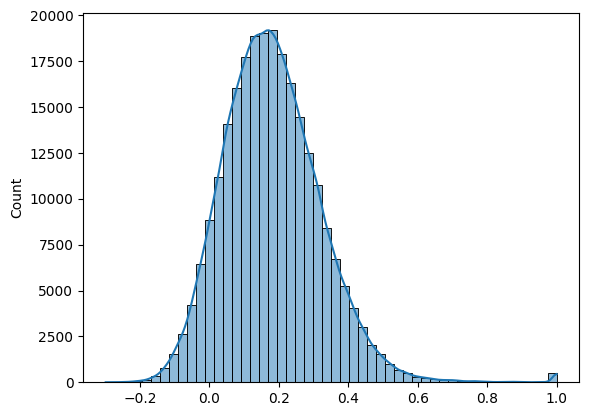

In [20]:
# visualizando um histograma de todas as similaridades do "what"
sns.histplot(what_similarities.flatten(), bins=50, kde=True)

In [21]:
# maior similaridade semântica
aux_similarities = what_similarities.copy()
np.fill_diagonal(aux_similarities, -np.inf) # ignorar a diagonal
max_similaridade_idx = aux_similarities.argmax()
u, v = np.unravel_index(max_similaridade_idx, aux_similarities.shape)
print("Eventos mais similares semanticamente:" )
print("\tEvento 1:", events_df.iloc[u]["what"])
print("\tEvento 2:", events_df.iloc[v]["what"])
print("Similaridade:", aux_similarities[u, v])

Eventos mais similares semanticamente:
	Evento 1: Sinn Féin faces backlash after double by-election defeats
	Evento 2: Sinn Féin faces backlash after double by-election defeat
Similaridade: 0.9972722


In [22]:
# menor similaridade semântica (excluindo a diagonal)
min_similaridade_idx = what_similarities.argmin()
u, v = np.unravel_index(min_similaridade_idx, what_similarities.shape)
print("Eventos menos similares semanticamente:")
print("\tEvento 1:", events_df.iloc[u]["what"])
print("\tEvento 2:", events_df.iloc[v]["what"])
print("Similaridade:", what_similarities[u, v])

Eventos menos similares semanticamente:
	Evento 1: King Charles III opens new session of British parliament amid political crisis after local elections
	Evento 2: Publication of the biographical profile for Keiko Fujimori.
Similaridade: -0.2984376


/home/kenzosaki/micromamba/envs/glm/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/kenzosaki/micromamba/envs/glm/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


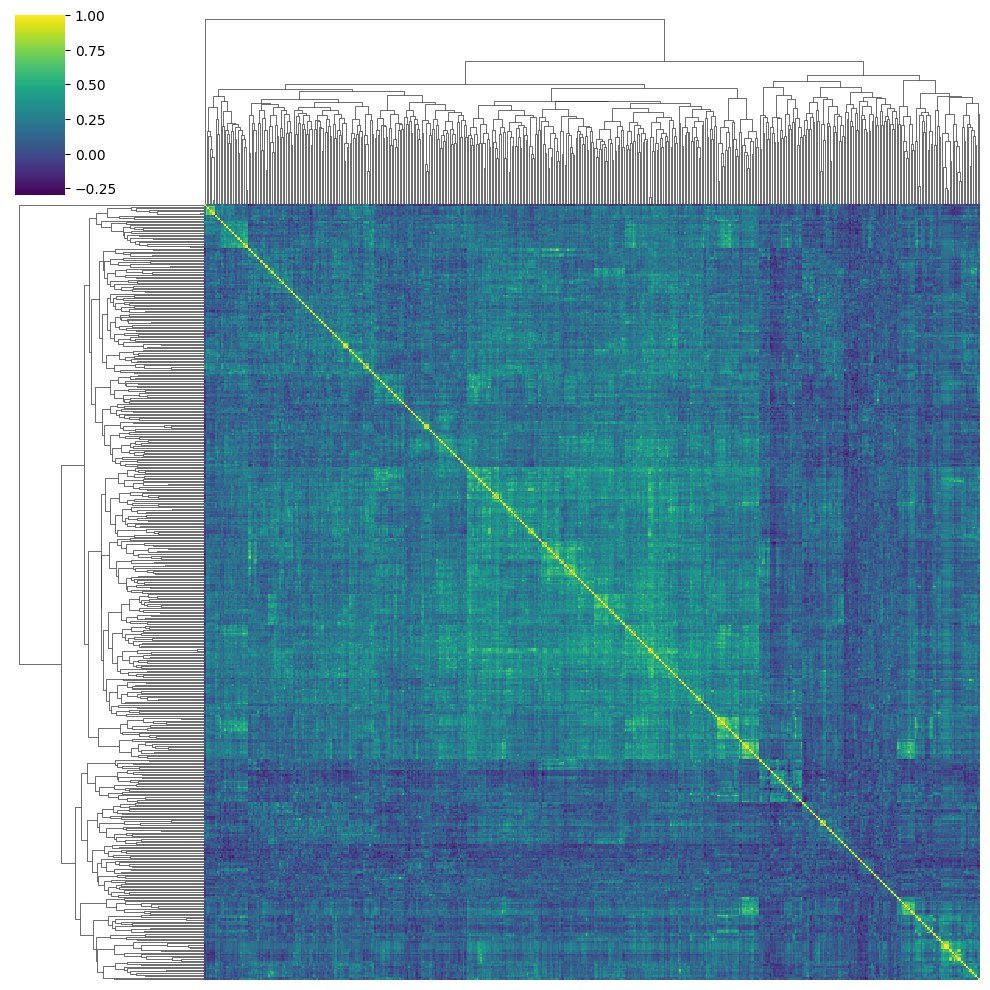

In [23]:
# heatmap das distancias
if GENERATE_VIS:
    sns.clustermap(what_similarities, cmap="viridis", xticklabels=False, yticklabels=False)

## Distancia espacial

A partir das coordenadas extraídas (latitude e longitude), computar a distância em kilômetros usando a função haversine.

In [24]:
import matplotlib.pyplot as plt

In [25]:
where_distance_matrix = builder.where_distances
where_similarity_matrix = builder.distance_similarity_scores

Text(0.5, 1.0, 'Similaridades Espaciais')

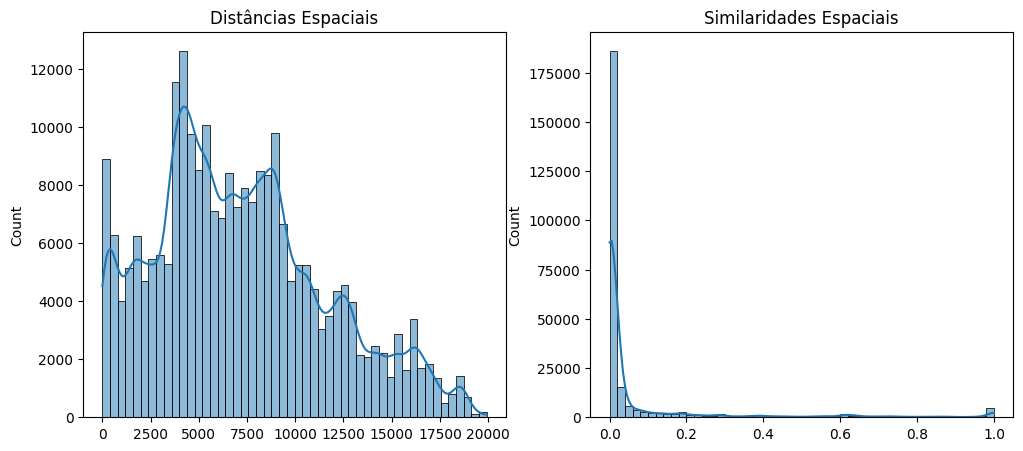

In [26]:
# visualizando um histograma de todas as similaridades do "where" e sua versao de similaridade
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)    
sns.histplot(where_distance_matrix.flatten(), bins=50, kde=True)
plt.title("Distâncias Espaciais")
plt.subplot(1, 2, 2)
sns.histplot(where_similarity_matrix.flatten(), bins=50, kde=True)
plt.title("Similaridades Espaciais")

In [27]:
# eventos mais distantes geograficamente
max_dist_idx = where_distance_matrix.argmax()
u, v = np.unravel_index(max_dist_idx, where_distance_matrix.shape)
print("Eventos mais distantes geograficamente:" )
print("\tEvento 1:", events_df.iloc[u]["where"])
print("\tEvento 2:", events_df.iloc[v]["where"])
print("Distância:", where_distance_matrix[u, v])

Eventos mais distantes geograficamente:
	Evento 1: New Zealand
	Evento 2: Spain
Distância: 19925


In [28]:
# eventos mais proximos geograficamente (excluindo a diagonal)
aux_distance_matrix = where_distance_matrix.copy()
np.fill_diagonal(aux_distance_matrix.astype(float), np.inf) # ignorar a diagonal
min_dist_idx = aux_distance_matrix.argmin()
u, v = np.unravel_index(min_dist_idx, aux_distance_matrix.shape)
print("Eventos mais proximos geograficamente:" )
print("\tEvento 1:", events_df.iloc[u]["where"])
print("\tEvento 2:", events_df.iloc[v]["where"])
print("Distância:", where_distance_matrix[u, v])

Eventos mais proximos geograficamente:
	Evento 1: Ethiopia
	Evento 2: Ethiopia
Distância: 0


/home/kenzosaki/micromamba/envs/glm/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/kenzosaki/micromamba/envs/glm/lib/python3.12/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/home/kenzosaki/micromamba/envs/glm/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/kenzosaki/micromamba/envs/glm/lib/python3.12/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


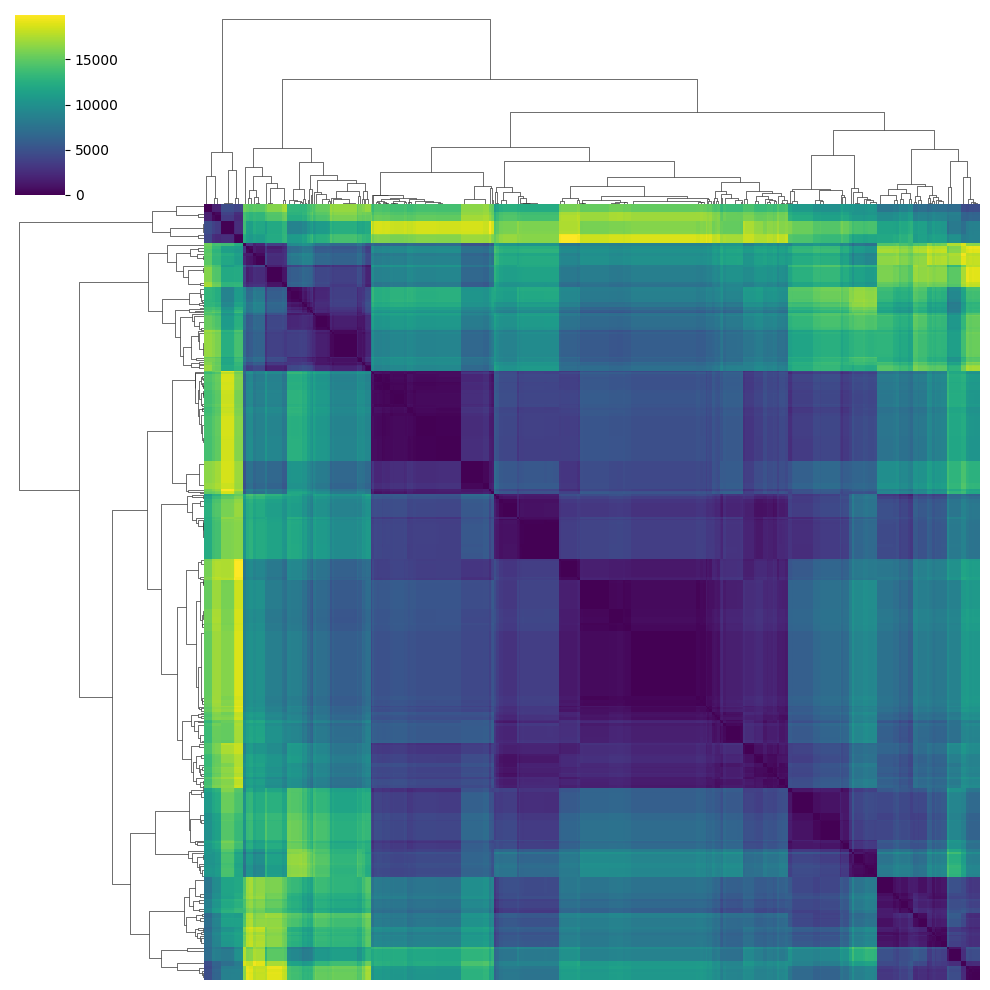

In [29]:
# heatmap das distancias
if GENERATE_VIS:
    sns.clustermap(where_distance_matrix, cmap="viridis", xticklabels=False, yticklabels=False)

# Distância temporal

Várias opções para testar aqui.
- Quantidade de absoluta de dias de diferença
- Alguma distância cíclica

In [30]:
when_distance_matrix = builder.when_distances
when_similarity_matrix = builder.temporal_similarity_scores

Text(0.5, 1.0, 'Similaridades Temporais')

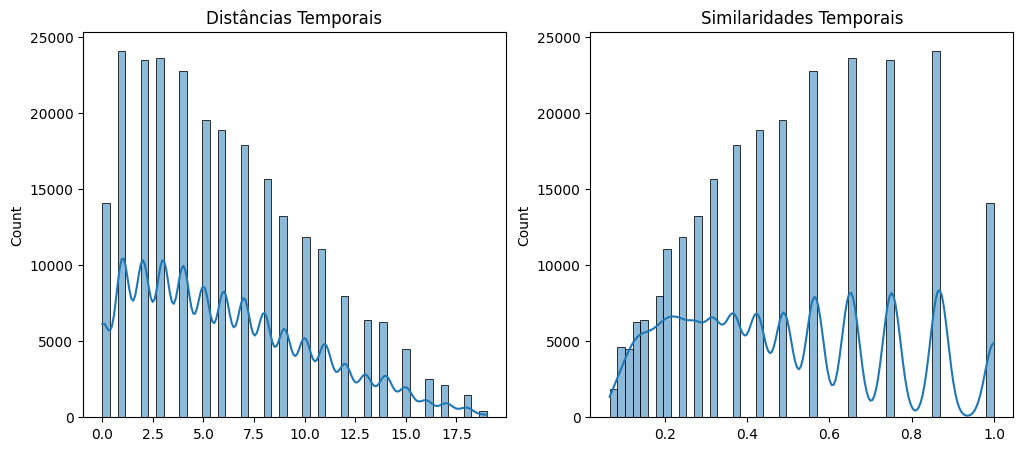

In [31]:
# visualziando um histograma de todas as similaridades do "when" e sua versao de similaridade
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(when_distance_matrix.flatten(), bins=50, kde=True)
plt.title("Distâncias Temporais")
plt.subplot(1, 2, 2)
sns.histplot(when_similarity_matrix.flatten(), bins=50, kde=True)
plt.title("Similaridades Temporais")

In [32]:
# maior distancia temporal
max_time_dist_idx = when_distance_matrix.argmax()
u, v = np.unravel_index(max_time_dist_idx, when_distance_matrix.shape)
print("Eventos mais distantes temporalmente:" )
print("\tEvento 1:", events_df.iloc[u]["when"])
print("\tEvento 2:", events_df.iloc[v]["when"])
print("Distância em dias:", when_distance_matrix[u, v])

Eventos mais distantes temporalmente:
	Evento 1: 2026-06-01 07:00:00+00:00
	Evento 2: 2026-05-13 07:00:00+00:00
Distância em dias: 19


In [33]:
# menor distância temporal
aux_time_distance_matrix = when_distance_matrix.copy()
np.fill_diagonal(aux_time_distance_matrix, 1e5) # ignorar a diagonal
min_time_dist_idx = aux_time_distance_matrix.argmin()
u, v = np.unravel_index(min_time_dist_idx, aux_time_distance_matrix.shape)
print("Eventos mais proximos temporalmente:" )
print("\tEvento 1:", events_df.iloc[u]["when"])
print("\tEvento 2:", events_df.iloc[v]["when"])
print("Distância em dias:", aux_time_distance_matrix[u, v]) 

Eventos mais proximos temporalmente:
	Evento 1: 2026-05-31 20:39:10+00:00
	Evento 2: 2026-05-31 20:20:49+00:00
Distância em dias: 0


/home/kenzosaki/micromamba/envs/glm/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/kenzosaki/micromamba/envs/glm/lib/python3.12/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/home/kenzosaki/micromamba/envs/glm/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/kenzosaki/micromamba/envs/glm/lib/python3.12/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


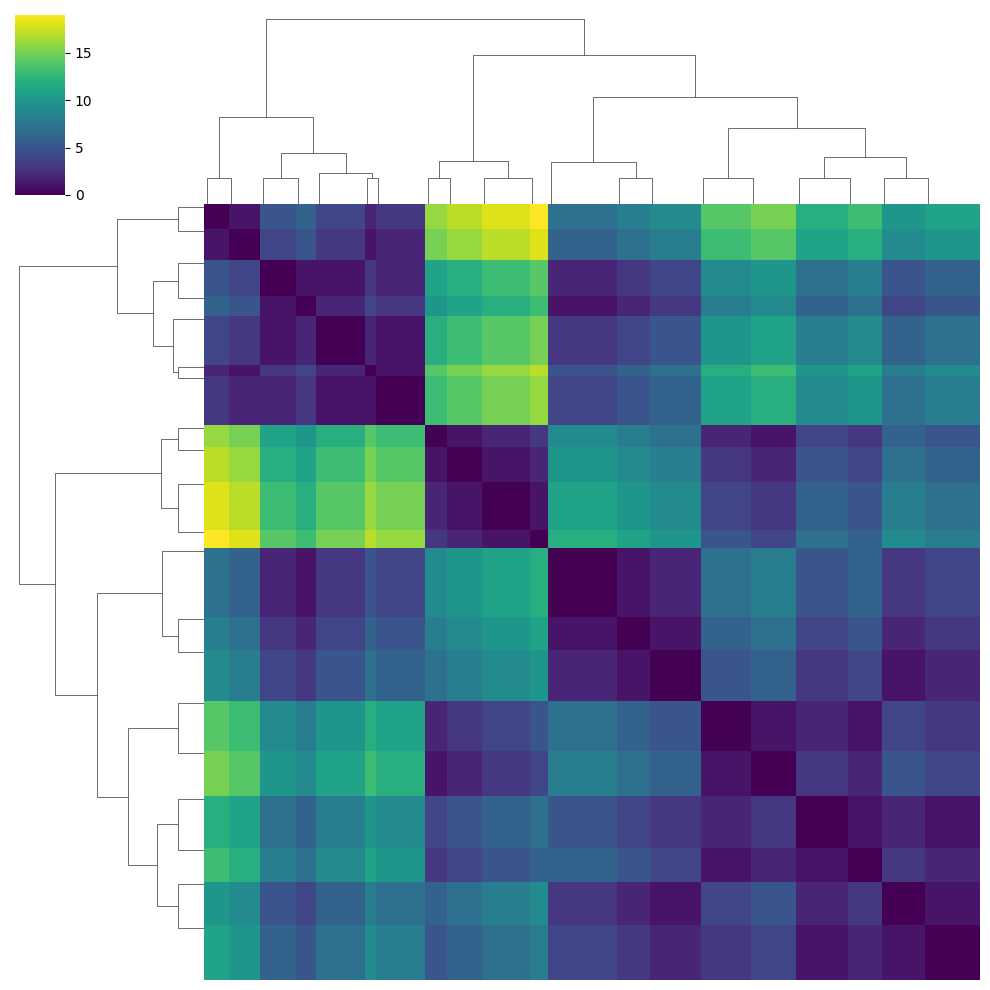

In [34]:
# heatmap das distancias
if GENERATE_VIS:
    sns.clustermap(when_distance_matrix, cmap="viridis", xticklabels=False, yticklabels=False)

# Explorando matrizes de similaridade e distancias

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

In [36]:
sampled_event = np.random.randint(0, len(events_df) - 1)
print("Event:", events_df.iloc[sampled_event]["what"])

Event: NDC calls for national government and electoral reforms


Text(0.5, 1.0, 'Distância temporal (When)')

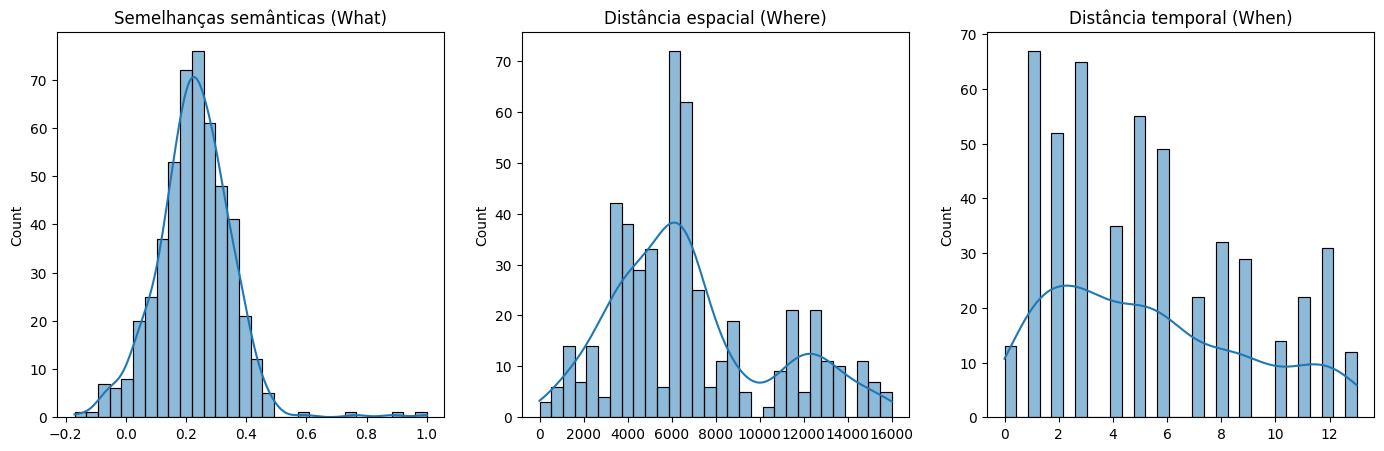

In [37]:
# verfificando distribuições de similaridade e distancia para o evento amostrado
# visualizando as distribuições lado a lado
similarity_scores = what_similarities[sampled_event]
distance_scores = where_distance_matrix[sampled_event]
temporal_distance_scores = when_distance_matrix[sampled_event]  
plt.figure(figsize=(17, 5))
plt.subplot(1, 3, 1)
sns.histplot(similarity_scores, bins=30, kde=True)
plt.title("Semelhanças semânticas (What)")
plt.subplot(1, 3, 2)
sns.histplot(distance_scores, bins=30, kde=True)
plt.title("Distância espacial (Where)")
plt.subplot(1, 3, 3)
sns.histplot(temporal_distance_scores, bins=30, kde=True)
plt.title("Distância temporal (When)")

Text(0.5, 1.0, 'What x Where x When')

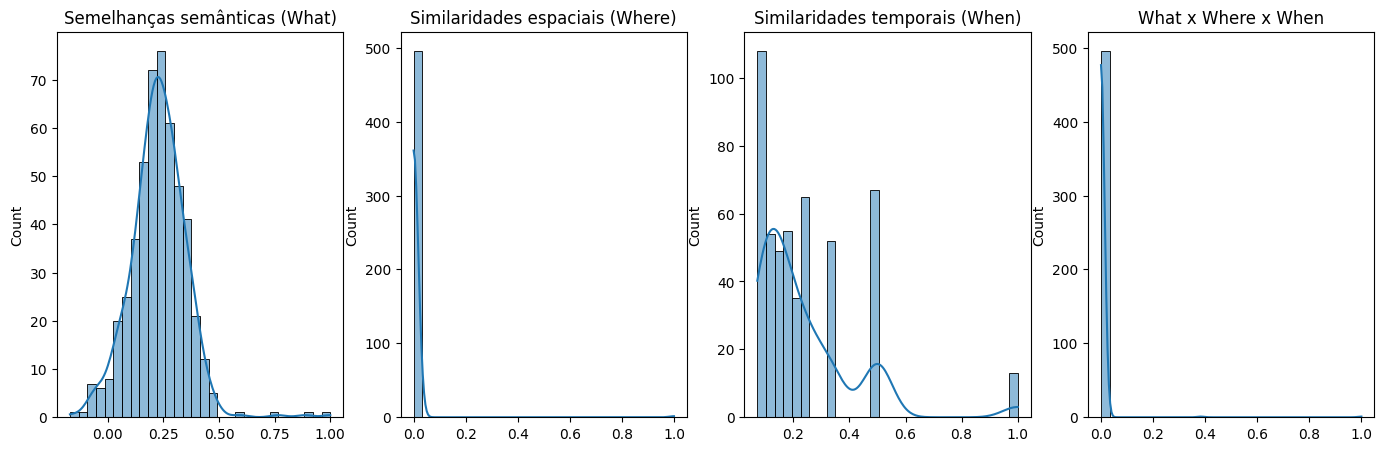

In [38]:
# verfificando distribuições de similaridade e distancia para o evento amostrado
# visualizando as distribuições lado a lado
similarity_scores = what_similarities[sampled_event]
distance_scores = where_distance_matrix[sampled_event]
temporal_distance_scores = when_distance_matrix[sampled_event]  

distance_similarity_scores = 1 / (1 + distance_scores) # transformando distancias em similaridades (quanto menor a distancia, maior a similaridade)
temporal_similarity_scores = 1 / (1 + temporal_distance_scores) # transformando distancias em similaridades (quanto menor a distancia, maior a similaridade)


plt.figure(figsize=(17, 5))
plt.subplot(1, 4, 1)
sns.histplot(similarity_scores, bins=30, kde=True)
plt.title("Semelhanças semânticas (What)")
plt.subplot(1, 4, 2)
sns.histplot(distance_similarity_scores, bins=30, kde=True)
plt.title("Similaridades espaciais (Where)")
plt.subplot(1, 4, 3)
sns.histplot(temporal_similarity_scores, bins=30, kde=True)
plt.title("Similaridades temporais (When)")
plt.subplot(1, 4, 4)
sns.histplot(similarity_scores * distance_similarity_scores * temporal_similarity_scores, bins=30, kde=True)
plt.title("What x Where x When")

# Montagem do grafo de eventos

A construção do grafo do evento está sujeita às seguintes restrições:
1. Conectar nós com base em **similaridade**.
2. Misturar informações semânticas, temporais e de distância para definir a "similaridade".
3. Caso existam várias componentes conexas, conectá-las usando o mínimo de arestas o possível.

Algoritmo para montagem do grafo de eventos.

1. Computar uma matriz de **similaridade**.
2. Definir um limiar de similaridade para definir vizinhos imediatos. Supondo o uso de um filtro de z-score, o parâmetro a ser calibrado é o 'n_std' usado na fórmula a seguir $limiar = média\ de\ similaridade + n\_std * desvio$ . Naturalmente, quanto maior for 'n_std', mais restritiva será a criação de arestas.
3. I) Ligando nós fortemente similares
    -  Para cada nó *u*, todos os nós *v_i* cuja similaridade com o nó *u* for maior que o limiar computado serão adicionados como vizinhos do nó *u*.
    - Note que esta etapa naturalmente pode originar várias componentes conexas.
4. II) Ligando componentes conexas
    - Enquanto existir um número de componentes conexas > 1:
        - Determinar as duas maiores componentes conexas em termos de quantidade de nós.
        - Ligá-las usando **uma única componente aresta**. A aresta irá ligar os nós de componentes diferentes que tiverem a maior similaridade dentre todos os pares possíveis.

# Abordagem ingênua/inicial - similaridade unificada

Dada a descrição acima, neste primeiro momento o foco está sendo em customizar o que seria a "similaridade" usada para compor as relações.

Foram avaliadas as seguintes estratégias.

1. Similaridades de uma única modalidade - semântica, temporal e espacial.
2. Fusão por multiplicação: $similaridade = similaridade_{semantica} \times similaridade_{temporal} \times similaridade_{espacial}$
3. Fusão baseada em soma não-ponderada:  $similaridade = similaridade_{semantica} + similaridade_{temporal} + similaridade_{espacial}$
4. Fusão com soma ponderada:  $similaridade = W_s \times similaridade_{semantica} + W_t \times similaridade_{temporal} + W_e \times similaridade_{espacial}$

/home/kenzosaki/micromamba/envs/glm/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/kenzosaki/micromamba/envs/glm/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


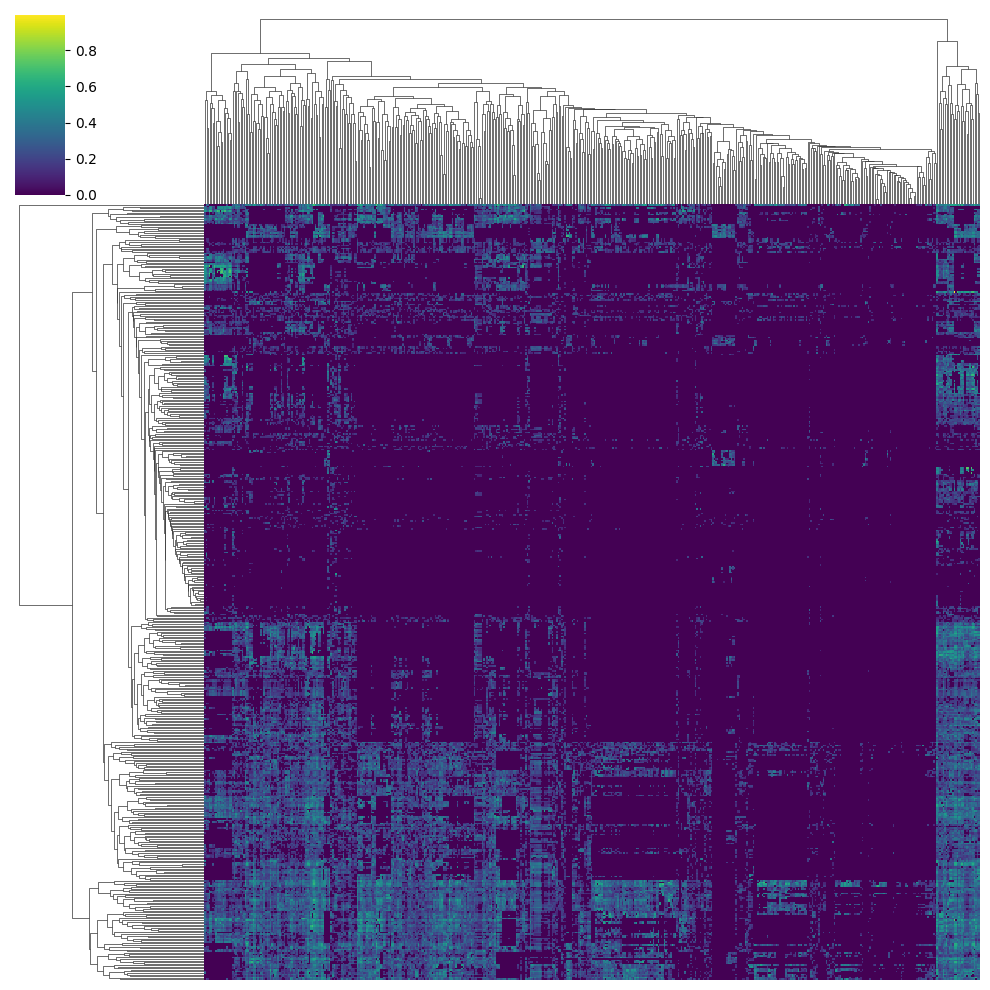

In [39]:
# visualizando matriz res
if GENERATE_VIS:
    ref_sim_mat = builder.reference_similarities
    sns.clustermap(ref_sim_mat, cmap="viridis", xticklabels=False, yticklabels=False)

# Executando um algoritmo de detecção de comunidades

Para auxiliar na visualização do grafo gerado.

In [40]:
import networkx as nx

In [41]:
communities = nx.community.louvain_communities(G, weight="weight")

# Visualizando grafo gerado

In [ ]:
from glm_based_event_analysis.utils.visualization import visualize_jupyter_graph

In [58]:
w = None
if GENERATE_VIS:
    
    w = visualize_jupyter_graph(G, communities)
w

GraphWidget(layout=Layout(height='800px', width='100%'))

# Visualizando usando PyVis

In [ ]:
from glm_based_event_analysis.graph_construction.visualization import generate_pyvis_graph

In [45]:
# Create PyVis network
if GENERATE_VIS:
    
    generate_pyvis_graph(G, communities, output_path="../data/politics_demo.html")

# Computando e visualizando propriedades

Text(0.5, 1.0, 'Distribuição de caminhos mínimos')

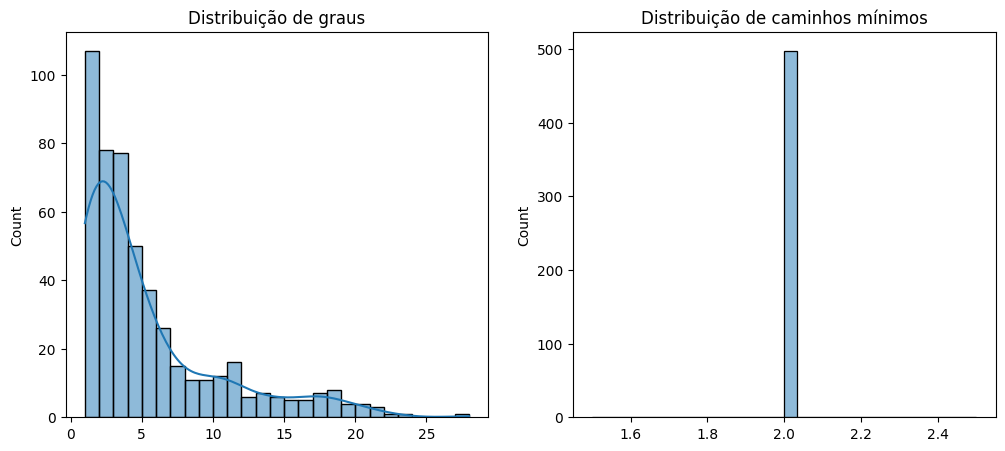

In [46]:
plt.figure(figsize=(12, 5))
degrees = dict(G.degree())
plt.subplot(1, 2, 1)
sns.histplot(list(degrees.values()), kde=True)
plt.title("Distribuição de graus")

small_path_sizes = [len(path) for path in nx.all_pairs_shortest_path(G)]
plt.subplot(1, 2, 2)
sns.histplot(small_path_sizes, bins=30, kde=True)
plt.title("Distribuição de caminhos mínimos")

In [47]:
assortativity = nx.degree_assortativity_coefficient(G)
print("Assortatividade do grafo:", assortativity)
diameter = nx.diameter(G.to_undirected())
print("Diâmetro do grafo:", diameter)
print("Tamanho médio de caminhos mínimos:", np.mean(small_path_sizes))

Assortatividade do grafo: 0.3247691616930632
Diâmetro do grafo: 15
Tamanho médio de caminhos mínimos: 2.0


# Explorando os pesos das arestas

<Axes: >

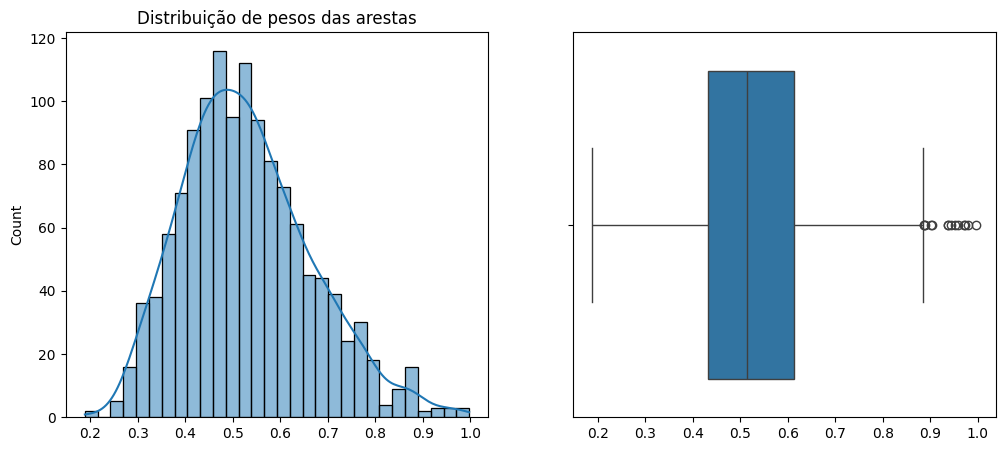

In [48]:
all_weights = [G.edges[edge]['weight'] for edge in G.edges()]
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(all_weights, bins=30, kde=True)
plt.title("Distribuição de pesos das arestas")
plt.subplot(1, 2, 2)
sns.boxplot(x=all_weights)

# Filtrando arestas com peso maior/menor

In [49]:
sorted_edges = sorted(G.edges(data=True), key=lambda x: x[2]['weight'], reverse=True)

In [50]:
for u, v, data in sorted_edges[:10]: # top 10 arestas mais fortes
    print(f"Aresta entre {u} e {v} com peso {data['weight']:.4f}")  
    print(f"Evento 1")
    print(f"\t what: {G.nodes[u]['what']}")
    print(f"\t where: {G.nodes[u]['where']}")
    print(f"\t when: {G.nodes[u]['when']}")
    print(f"Evento 2")
    print(f"\t what: {G.nodes[v]['what']}")
    print(f"\t where: {G.nodes[v]['where']}")
    print(f"\t when: {G.nodes[v]['when']}")
    print("---")

Aresta entre 104_sinn_féin_by-election_defeat_2026-05-28 e 95_sinn_féin_by-election_defeats_2026-05-28 com peso 0.9973
Evento 1
	 what: Sinn Féin faces backlash after double by-election defeat
	 where: Ireland
	 when: 2026-05-28 05:17:33+00:00
Evento 2
	 what: Sinn Féin faces backlash after double by-election defeats
	 where: Ireland
	 when: 2026-05-28 05:17:33+00:00
---
Aresta entre 186_senegal_parliament_speaker_political_crisis_2026-05-24 e 165_senegal_parliament_speaker_steps_down_2026-05-25 com peso 0.9791
Evento 1
	 what: The speaker of the Senegal parliament has stepped down as the country faces a worsening political crisis.
	 where: Senegal
	 when: 2026-05-24 07:00:00+00:00
Evento 2
	 what: The speaker of the Senegal parliament has stepped down amid a political crisis.
	 where: Senegal
	 when: 2026-05-25 07:00:00+00:00
---
Aresta entre 435_uk_ungovernable_institute_2026-05-15 e 440_britain_ungovernable_2026-05-16 com peso 0.9723
Evento 1
	 what: An inquiry into whether the Unit

In [51]:
sorted_edges = sorted(G.edges(data=True), key=lambda x: x[2]['weight'])

for u, v, data in sorted_edges[:10]: # top 10 arestas mais fortes
    print(f"Aresta entre {u} e {v} com peso {data['weight']:.4f}")  
    print(f"Evento 1")
    print(f"\t what: {G.nodes[u]['what']}")
    print(f"\t where: {G.nodes[u]['where']}")
    print(f"\t when: {G.nodes[u]['when']}")
    print(f"Evento 2")
    print(f"\t what: {G.nodes[v]['what']}")
    print(f"\t where: {G.nodes[v]['where']}")
    print(f"\t when: {G.nodes[v]['when']}")
    print("---")

Aresta entre 17_sweden_aid_energy_crisis_2026-06-01 e 10_inflation_warning_bond_market_2026-06-01 com peso 0.1884
Evento 1
	 what: Sweden increases financial aid to households and businesses to address the energy crisis.
	 where: Sweden
	 when: 2026-06-01 01:13:52+00:00
Evento 2
	 what: Trump is facing a new inflation warning from the bond market, adding to his midterm challenges.
	 where: United States
	 when: 2026-06-01 04:44:13+00:00
---
Aresta entre 25_president_faye_nationalist_party_government_2026-06-01 e 1_democracy_africa_coups_2026-06-01 com peso 0.1993
Evento 1
	 what: Senegal President Faye excludes the Nationalist Party from his newly formed government.
	 where: Senegal
	 when: 2026-06-01 07:00:00+00:00
Evento 2
	 what: The ongoing crisis of democracy in Africa characterized by military coups and political instability.
	 where: Mali
	 when: 2026-06-01 07:00:00+00:00
---
Aresta entre 71_migrants_unemployment_malema_2026-05-29 e 26_sumar_leadership_psoe_2026-05-31 com peso 0

# Amostrando arestas aleatóriamente

In [52]:
sampled_edges = random.sample(list(G.edges(data=True)), 10)

for u, v, data in sampled_edges: # top 10 arestas mais fortes
    print(f"Aresta entre {u} e {v} com peso {data['weight']:.4f}")  
    print(f"- Informações da aresta")
    for key, value in data.items():
        print(f"\t{key}: {value}")
    print(f"Evento 1")
    print(f"\t what: {G.nodes[u]['what']}")
    print(f"\t where: {G.nodes[u]['where']}")
    print(f"\t when: {G.nodes[u]['when']}")
    print(f"Evento 2")
    print(f"\t what: {G.nodes[v]['what']}")
    print(f"\t where: {G.nodes[v]['where']}")
    print(f"\t when: {G.nodes[v]['when']}")
    print("---")

Aresta entre 388_parliament_government_rumen_radev_2026-05-17 e 37_janez_janša_government_slovenia_2026-05-29 com peso 0.4072
- Informações da aresta
	weight: 0.40724310278892517
	what_sim: 0.40724310278892517
	where_sim: 0.46579949764982825
	when_sim: 0.1800923121479524
	edge_type: similarity
Evento 1
	 what: Bulgaria's Parliament approves a new government led by Rumen Radev.
	 where: Bulgaria
	 when: 2026-05-17 13:32:00+00:00
Evento 2
	 what: The fourth government of Janez Janša is becoming a reality in Slovenia.
	 where: Slovenia
	 when: 2026-05-29 12:35:32+00:00
---
Aresta entre 418_scottish_greens_holyrood_debate_uk_2026-05-18 e 364_brexit_labour_leadership_2026-05-18 com peso 0.4387
- Informações da aresta
	weight: 0.4386988580226898
	what_sim: 0.4386988580226898
	where_sim: 1.0
	when_sim: 1.0
	edge_type: similarity
Evento 1
	 what: The Scottish Greens are calling for the first Holyrood debate to focus on the breakup of the United Kingdom.
	 where: United Kingdom
	 when: 2026-05-

# Visualizando limiares por evento

In [ ]:
from glm_based_event_analysis.graph_construction.graph_builder import zscore_thresholding, iqr_thresholding, percentile_thresholding, mad_thresholding

In [54]:
ref_sim_mat = builder.reference_similarities

Event: A 20-year review analyzing trends in global confidence in institutions.
Filtering non-positive similarity scores for thresholding...
- Number of similarity scores after filtering: 133


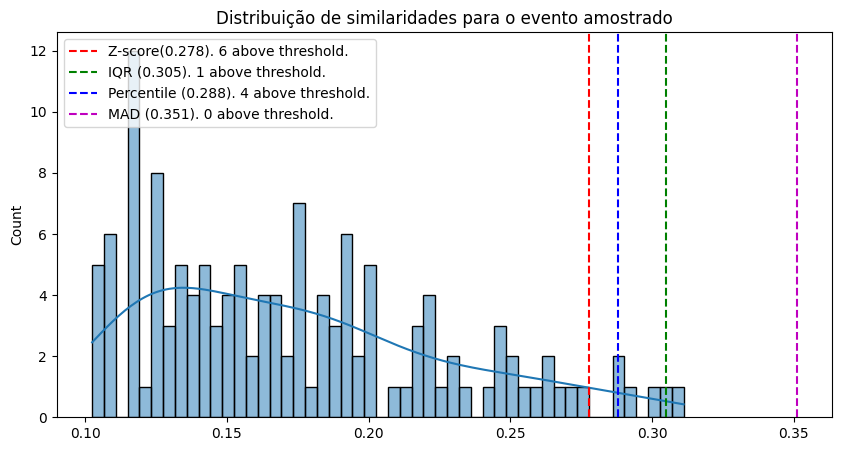

In [55]:
sampled_seq_event = np.random.randint(0, len(events_df) - 1)
print("Event:", events_df.iloc[sampled_seq_event]["what"])

# visualizando os limiares na distribuição de similaridades do evento amostrado
similarity_scores = ref_sim_mat[sampled_seq_event]

if config['constraints']['use_non_zero_similarities']:
        print('Filtering non-positive similarity scores for thresholding...')
        similarity_scores = similarity_scores[similarity_scores > 0]
        print(f"- Number of similarity scores after filtering: {len(similarity_scores)}")

zscore_threshold = zscore_thresholding(similarity_scores, n_std=2)
iqr_threshold = iqr_thresholding(similarity_scores, k=1.5)
percentile_threshold = percentile_thresholding(similarity_scores, percentile=97)
mad_threshold = mad_thresholding(similarity_scores, n=3.5)


plt.figure(figsize=(10, 5))
sns.histplot(similarity_scores, bins=50, kde=True)
plt.axvline(zscore_threshold, color='r', linestyle='--', label=f'Z-score({zscore_threshold:.3f}). {sum(similarity_scores >= zscore_threshold)} above threshold.')
plt.axvline(iqr_threshold, color='g', linestyle='--', label=f'IQR ({iqr_threshold:.3f}). {sum(similarity_scores >= iqr_threshold)} above threshold.')
plt.axvline(percentile_threshold, color='b', linestyle='--', label=f'Percentile ({percentile_threshold:.3f}). {sum(similarity_scores >= percentile_threshold)} above threshold.')
plt.axvline(mad_threshold, color='m', linestyle='--', label=f'MAD ({mad_threshold:.3f}). {sum(similarity_scores >= mad_threshold)} above threshold.')
plt.title("Distribuição de similaridades para o evento amostrado")
plt.legend()

# Visualizando limiares considerando todas as similaridades

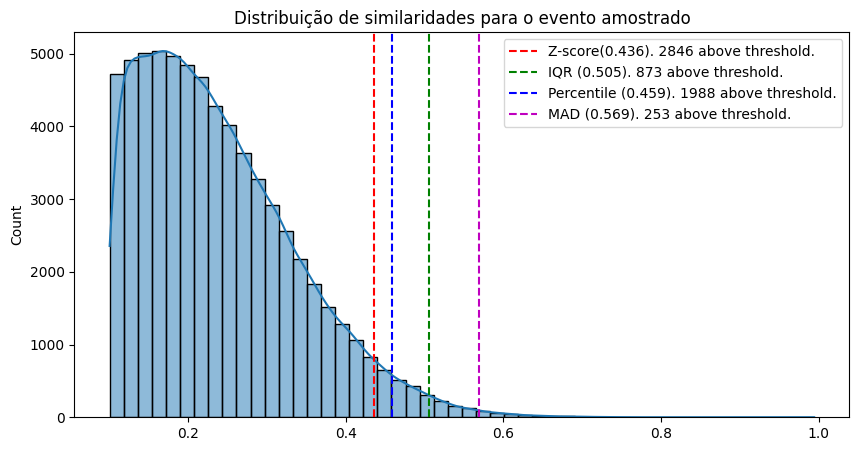

In [56]:
# flatten de todas as similaridades
all_sims = ref_sim_mat.flatten()

if config['constraints']['use_non_zero_similarities']:
        all_sims = all_sims[all_sims > 0]
        # all_sims = np.log(1+all_sims) # log-transform para ajudar na visualização
        
zscore_threshold = zscore_thresholding(all_sims, n_std=2)
iqr_threshold = iqr_thresholding(all_sims, k=1.5)
percentile_threshold = percentile_thresholding(all_sims, percentile=97)
mad_threshold = mad_thresholding(all_sims, n=3.5)


plt.figure(figsize=(10, 5))
sns.histplot(all_sims, bins=50, kde=True)
plt.axvline(zscore_threshold, color='r', linestyle='--', label=f'Z-score({zscore_threshold:.3f}). {sum(all_sims >= zscore_threshold)} above threshold.')
plt.axvline(iqr_threshold, color='g', linestyle='--', label=f'IQR ({iqr_threshold:.3f}). {sum(all_sims >= iqr_threshold)} above threshold.')
plt.axvline(percentile_threshold, color='b', linestyle='--', label=f'Percentile ({percentile_threshold:.3f}). {sum(all_sims >= percentile_threshold)} above threshold.')
plt.axvline(mad_threshold, color='m', linestyle='--', label=f'MAD ({mad_threshold:.3f}). {sum(all_sims >= mad_threshold)} above threshold.')
plt.title("Distribuição de similaridades para o evento amostrado")
plt.legend()